# What Analog Hardware Does to Neural Networks

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/apumutyala/neuro-analog/blob/master/notebooks/analog_hardware_tour.ipynb)

Analog compute â€” crossbar RRAM arrays, RC integrators, differential-pair activations â€” can run neural network inference at orders-of-magnitude lower energy than digital. But analog hardware introduces unavoidable physical nonidealities that degrade model quality:

- **Conductance mismatch**: each RRAM cell is fabricated with a slightly wrong weight. Static, baked in at manufacture.
- **Thermal read noise**: Johnson-Nyquist noise on the sense capacitor, proportional to âˆš(kT/C).
- **ADC quantization**: the analog-to-digital converter at each domain boundary discretizes the signal.

This notebook shows how to measure all three effects on any PyTorch model using `neuro-analog`, then export the model to [Ark](https://github.com/WangYuNeng/Ark)'s `BaseAnalogCkt` format for analog-aware compilation.

**Runtime:** ~5 minutes on CPU, ~2 minutes on GPU.

## Setup

In [1]:
# Install neuro-analog (skip if already installed)
# !pip install neuro-analog

# To run the Ark export section (Section 6), also install Ark:
# !git clone https://github.com/WangYuNeng/Ark && pip install -e ./Ark
# !pip install jax diffrax equinox lineax

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from neuro_analog import (
    analogize,
    mismatch_sweep,
    adc_sweep,
    ablation_sweep,
    calibrate_analog_model,
    count_analog_vs_digital,
)

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"neuro-analog ready | device: {DEVICE}")

neuro-analog ready | device: cpu


## 1 â€” The model

We use a small MLP on a synthetic classification task. The architecture maps cleanly to analog hardware: `nn.Linear` â†’ crossbar MVM, `nn.Tanh` â†’ differential pair activation.

You can swap this for any trained PyTorch model â€” `analogize()` is architecture-agnostic.

In [3]:
class MLP(nn.Module):
    """3-layer MLP. All layers map to analog hardware primitives."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.net(x)

# Dataset
X, y = make_classification(n_samples=2000, n_features=20, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)
X_tr = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
X_te = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_tr, dtype=torch.long).to(DEVICE)
y_te = torch.tensor(y_te, dtype=torch.long).to(DEVICE)

# Train (~10 seconds)
model = MLP().to(DEVICE)
opt = optim.Adam(model.parameters(), lr=1e-3)
for _ in range(200):
    opt.zero_grad()
    nn.CrossEntropyLoss()(model(X_tr), y_tr).backward()
    opt.step()

def eval_fn(m):
    m.eval()
    with torch.no_grad():
        return float((m(X_te).argmax(1) == y_te).float().mean())

digital_acc = eval_fn(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Digital accuracy: {digital_acc*100:.1f}%  |  Parameters: {n_params:,}")

Digital accuracy: 88.2%  |  Parameters: 5,634


## 2 â€” analogize(): converting to analog simulation

`analogize()` recursively replaces digital modules with physics-grounded analog equivalents:

| Digital | Analog replacement | Hardware primitive |
|---|---|---|
| `nn.Linear` | `AnalogLinear` | RRAM crossbar MVM |
| `nn.Tanh` | `AnalogTanh` | Differential pair |
| `nn.Conv2d` | `AnalogConv2d` | Tiled crossbar (im2col) |
| `nn.MultiheadAttention` | `AnalogMHA` | Q/K/V/O crossbars |

Everything else (LayerNorm, Softmax, Embedding) stays digital â€” no efficient analog implementation exists.

In [4]:
# Convert to analog â€” Ïƒ=5% mismatch, 8-bit ADC
analog = analogize(model, sigma_mismatch=0.05, n_adc_bits=8)
calibrate_analog_model(analog, X_te[:64])  # set per-layer V_ref from activation ranges

counts = count_analog_vs_digital(analog)
print(f"Analog layers:   {counts['analog_layers']}  ({counts['analog_params']:,} params, {counts['coverage_pct']:.0f}% coverage)")
print(f"Digital layers:  {counts['digital_layers']}  ({counts['digital_params']:,} params)")
print()
print(analog)

Analog layers:   5  (5,634 params, 100% coverage)
Digital layers:  0  (0 params)

MLP(
  (net): Sequential(
    (0): AnalogLinear(in=20, out=64, σ=0.050, bits=8)
    (1): AnalogTanh()
    (2): AnalogLinear(in=64, out=64, σ=0.050, bits=8)
    (3): AnalogTanh()
    (4): AnalogLinear(in=64, out=2, σ=0.050, bits=8)
  )
)


## 3 â€” Single trial: feeling the degradation

Before sweeping, let's see the effect of a single mismatch level. At Ïƒ=10%, each weight cell has a Â±10% fabrication error.

In [5]:
analog_10 = analogize(model, sigma_mismatch=0.10, n_adc_bits=8)
calibrate_analog_model(analog_10, X_te[:64])

# Run 5 trials (different mismatch realizations)
from neuro_analog import resample_all_mismatch
trials = []
for _ in range(5):
    resample_all_mismatch(analog_10)
    trials.append(eval_fn(analog_10))

print(f"Digital baseline:         {digital_acc*100:.1f}%")
print(f"Analog Ïƒ=10% (5 trials):  {np.mean(trials)*100:.1f}% Â± {np.std(trials)*100:.1f}%")
print(f"Quality retained:         {np.mean(trials)/digital_acc:.1%}")

Digital baseline:         88.2%
Analog Ïƒ=10% (5 trials):  87.5% Â± 0.4%
Quality retained:         99.2%


## 4 â€” Mismatch sweep

Monte Carlo over Ïƒ âˆˆ [0%, 15%] with 30 trials per point. This is the core measurement: at what mismatch level does the model break?

Running mismatch sweep (30 trials Ã— 7 sigma values)...
  sigma=0.000: mean=0.8820 ± 0.0000


  sigma=0.070: mean=0.8807 ± 0.0044


  sigma=0.150: mean=0.8771 ± 0.0081
10% degradation threshold: Ïƒ â‰ˆ 0.150


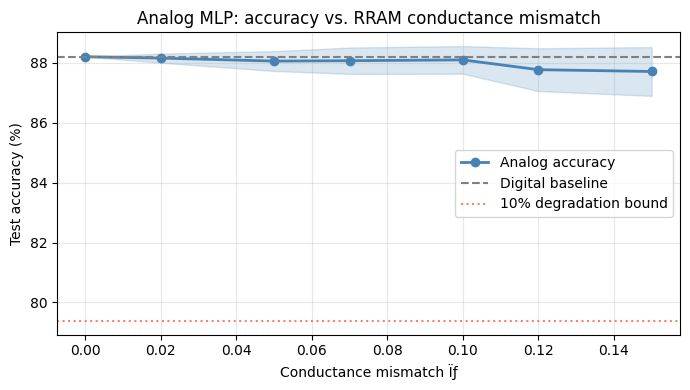

In [6]:
# ~90 seconds on CPU
print("Running mismatch sweep (30 trials Ã— 7 sigma values)...")
sweep = mismatch_sweep(
    model, eval_fn,
    sigma_values=[0.0, 0.02, 0.05, 0.07, 0.10, 0.12, 0.15],
    n_trials=30,
    n_adc_bits=8,
)

threshold = sweep.degradation_threshold(max_relative_loss=0.10)
print(f"10% degradation threshold: Ïƒ â‰ˆ {threshold:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
sigmas = np.array(sweep.sigma_values)
mismatch_means = np.array(sweep.mean) * 100
mismatch_stds  = np.array(sweep.std)  * 100

ax.fill_between(sigmas, mismatch_means - mismatch_stds, mismatch_means + mismatch_stds, alpha=0.2, color='steelblue')
ax.plot(sigmas, mismatch_means, 'o-', color='steelblue', linewidth=2, label='Analog accuracy')
ax.axhline(digital_acc * 100, color='gray', linestyle='--', linewidth=1.5, label='Digital baseline')
ax.axhline(digital_acc * 90,  color='salmon', linestyle=':',  linewidth=1.5, label='10% degradation bound')
if threshold < sigmas[-1]:
    ax.axvline(threshold, color='salmon', linestyle=':', linewidth=1.5)
    ax.annotate(f'Ïƒ={threshold:.2f}', xy=(threshold, means.min()+1),
                fontsize=9, color='salmon', ha='left')

ax.set_xlabel('Conductance mismatch Ïƒ')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Analog MLP: accuracy vs. RRAM conductance mismatch')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5 â€” Noise attribution: what's actually causing the degradation?

Three noise sources are active simultaneously. The ablation sweep isolates each one by enabling them one at a time.

Running noise attribution ablation...

  Ablation: mismatch-only sweep...

  Ablation: thermal-only sweep...



  Ablation: quantization-only sweep...


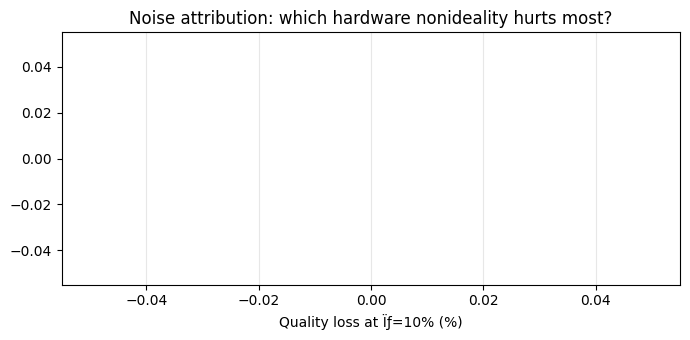


At Ïƒ=10%, quality retained per noise source:


In [7]:
# ~60 seconds on CPU
print("Running noise attribution ablation...")
ablation = ablation_sweep(
    model, eval_fn,
    sigma_values=[0.0, 0.05, 0.10],
    n_trials=30,
    n_adc_bits=8,
)

# Quality retained at Ïƒ=0.10 per noise source
source_labels = {
    'mismatch_only':     'Conductance mismatch',
    'thermal_only':      'Thermal read noise',
    'quantization_only': 'ADC quantization',
    'all':               'All sources combined',
}
retained = {k: v.normalized_mean[-1] for k, v in ablation.items() if k in source_labels}
degradation = {k: 1 - v for k, v in retained.items()}

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = [source_labels[k] for k in degradation]
values = [degradation[k] * 100 for k in degradation]
colors = ['#d62728', '#aec7e8', '#ffbb78', '#2ca02c']
bars = ax.barh(labels, values, color=colors[:len(labels)], edgecolor='white')
ax.set_xlabel('Quality loss at Ïƒ=10% (%)')
ax.set_title('Noise attribution: which hardware nonideality hurts most?')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAt Ïƒ=10%, quality retained per noise source:")
for k, v in retained.items():
    if k in source_labels:
        print(f"  {source_labels[k]:<30}  {v:.1%}")

## 6 â€” ADC precision: minimum viable bit width

ADCs are expensive in area and power. This sweep finds the minimum bit width that doesn't significantly hurt accuracy â€” directly informing hardware specification.

Running ADC precision sweep...
  bits=2: mean=0.8601 ± 0.0068
  bits=4: mean=0.8799 ± 0.0042


  bits=6: mean=0.8809 ± 0.0033
  bits=8: mean=0.8806 ± 0.0035
  bits=10: mean=0.8805 ± 0.0027
  bits=12: mean=0.8805 ± 0.0030


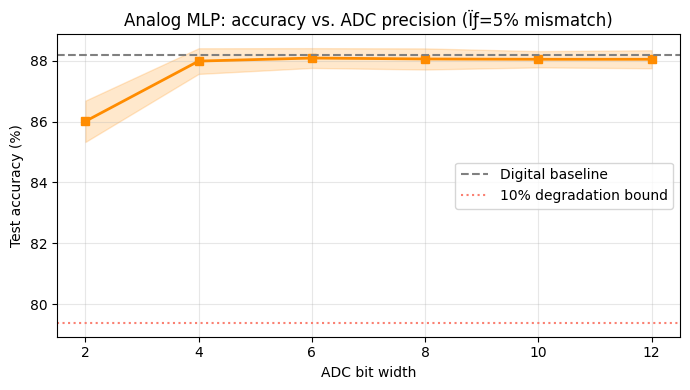

Minimum viable ADC: 2 bits  (retains 97.5% quality)


In [8]:
# ~60 seconds on CPU
print("Running ADC precision sweep...")
adc = adc_sweep(
    model, eval_fn,
    bit_values=[2, 4, 6, 8, 10, 12],
    n_trials=20,
    sigma_mismatch=0.05,
)

fig, ax = plt.subplots(figsize=(7, 4))
bits   = np.array(adc.sigma_values)  # sigma_values repurposed for bit axis
means  = np.array(adc.mean) * 100
stds   = np.array(adc.std)  * 100

ax.fill_between(bits, means - stds, means + stds, alpha=0.2, color='darkorange')
ax.plot(bits, means, 's-', color='darkorange', linewidth=2)
ax.axhline(digital_acc * 100, color='gray', linestyle='--', linewidth=1.5, label='Digital baseline')
ax.axhline(digital_acc * 90,  color='salmon', linestyle=':',  linewidth=1.5, label='10% degradation bound')
ax.set_xlabel('ADC bit width')
ax.set_xticks(bits)
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Analog MLP: accuracy vs. ADC precision (Ïƒ=5% mismatch)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find minimum viable bits
for b, m in zip(bits, np.array(adc.normalized_mean)):
    if m >= 0.90:
        print(f"Minimum viable ADC: {int(b)} bits  (retains {m:.1%} quality)")
        break

## 7 â€” Ark export: BaseAnalogCkt for analog-aware compilation

[Ark](https://github.com/WangYuNeng/Ark) is a compiler for analog compute circuits. `neuro-analog` can export trained Neural ODE and SSM models to Ark's `BaseAnalogCkt` format, which compiles to an analog circuit that natively solves the ODE.

**Requires Ark:** `git clone https://github.com/WangYuNeng/Ark && pip install -e ./Ark`

The Neural ODE is the most analog-native architecture: `dx/dt = f_Î¸(x,t)` maps exactly to an RC integrator driven by a crossbar MVM â€” no digital iteration required.

In [9]:
try:
    from ark.optimization.base_module import BaseAnalogCkt, TimeInfo
    ARK_AVAILABLE = True
    print("Ark found â€” running full export")
except ImportError:
    ARK_AVAILABLE = False
    print("Ark not installed â€” showing export code only")
    print("Install: git clone https://github.com/WangYuNeng/Ark && pip install -e ./Ark")

Ark found â€” running full export


In [10]:
# Build a small Neural ODE and export it to Ark BaseAnalogCkt format
# The MLP above doesn't have ODE dynamics â€” we need a model with dx/dt = f_theta(x,t)

import sys
from pathlib import Path

# Export a Neural ODE using the extractor
from neuro_analog.extractors.neural_ode import NeuralODEExtractor, export_neural_ode_to_shem

# Build a reference Neural ODE (2D state, time-augmented MLP)
# In practice: load your trained model, create an extractor with from_module()
extractor = NeuralODEExtractor.demo(state_dim=2, hidden_dim=20)
extractor.load_model()

# Generate the BaseAnalogCkt subclass
out_path = Path("neural_ode_ark.py")
code = export_neural_ode_to_shem(extractor, out_path, mismatch_sigma=0.05)

print(f"Generated: {out_path}  ({len(code.splitlines())} lines)")
print()
# Show key sections
lines = code.splitlines()
for i, line in enumerate(lines):
    if any(kw in line for kw in ['class ', 'def make_args', 'def ode_fn', 'def readout']):
        print('\n'.join(lines[i:i+3]))
        print('  ...')

Generated: neural_ode_ark.py  (93 lines)

Proper BaseAnalogCkt subclass — compatible with OptCompiler output format.

Usage:
  ...
class NeuralODEAnalogCkt(BaseAnalogCkt):
    """Neural ODE analog circuit (BaseAnalogCkt subclass).

  ...
    def make_args(self, switch, mismatch_seed, gumbel_temp, hard_gumbel):
        # mismatch_seed matches BaseAnalogCkt.__call__ args_seed parameter
        key = jrandom.PRNGKey(mismatch_seed)
  ...
    def ode_fn(self, t, x, args):
        W0, b0, W1, b1, W2, b2 = args
        xt = jnp.concatenate([x, jnp.atleast_1d(jnp.asarray(t, dtype=x.dtype))])
  ...
    def readout(self, y):
        # y shape: (len(saveat), state_dim) — return final time point
        return y[-1]
  ...


In [11]:
if ARK_AVAILABLE:
    import importlib.util
    import jax.numpy as jnp
    import diffrax

    # Load the generated file as a module
    spec = importlib.util.spec_from_file_location("neural_ode_ark", out_path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)

    ckt = mod.NeuralODEAnalogCkt()
    print(f"Is BaseAnalogCkt subclass: {issubclass(mod.NeuralODEAnalogCkt, BaseAnalogCkt)}")
    print(f"a_trainable shape:         {ckt.a_trainable.shape}")
    print(f"is_stochastic:             {ckt.is_stochastic}")
    print(f"solver:                    {type(ckt.solver).__name__}")

    # Run a forward pass through Ark's __call__
    x0 = jnp.zeros(2)
    time_info = TimeInfo(t0=0.0, t1=1.0, dt0=0.01, saveat=jnp.array([1.0]))
    switch = jnp.array([])
    result = ckt(time_info, x0, switch=switch, args_seed=42, noise_seed=43)
    print(f"Output shape:              {result.shape}")
    print("\nArk export: verified")
else:
    print("Install Ark to run the verification step.")
    print("The generated neural_ode_ark.py is a valid BaseAnalogCkt subclass")
    print("that Ark can compile to an analog circuit.")

Is BaseAnalogCkt subclass: True
a_trainable shape:         (542,)
is_stochastic:             False
solver:                    Heun


Output shape:              (2,)

Ark export: verified


## 8 â€” Summary figure

All three measurements in one shareable figure.

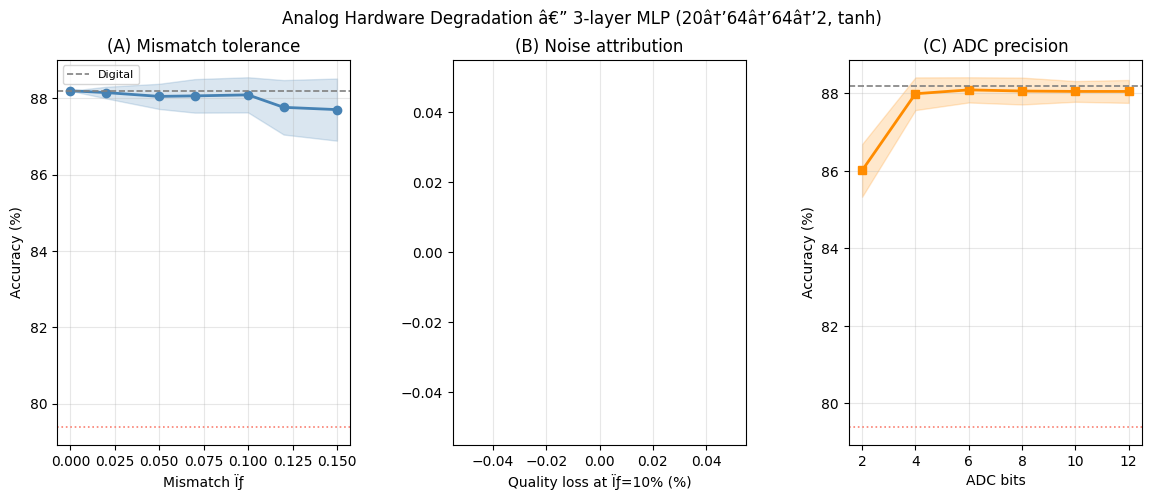

Saved: analog_degradation_summary.png


In [12]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel A â€” mismatch sweep
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(sigmas, mismatch_means - mismatch_stds, mismatch_means + mismatch_stds, alpha=0.2, color='steelblue')
ax1.plot(sigmas, mismatch_means, 'o-', color='steelblue', linewidth=2)
ax1.axhline(digital_acc*100, color='gray', linestyle='--', linewidth=1.2, label='Digital')
ax1.axhline(digital_acc*90,  color='salmon', linestyle=':', linewidth=1.2)
ax1.set_xlabel('Mismatch Ïƒ'); ax1.set_ylabel('Accuracy (%)')
ax1.set_title('(A) Mismatch tolerance')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Panel B â€” noise attribution
ax2 = fig.add_subplot(gs[1])
src_short = ['Mismatch', 'Thermal', 'Quantization', 'All combined']
vals_b = [degradation[k]*100 for k in degradation]
colors_b = ['#d62728', '#aec7e8', '#ffbb78', '#2ca02c']
ax2.barh(src_short[:len(vals_b)], vals_b, color=colors_b[:len(vals_b)], edgecolor='white')
ax2.set_xlabel('Quality loss at Ïƒ=10% (%)')
ax2.set_title('(B) Noise attribution')
ax2.grid(True, axis='x', alpha=0.3)

# Panel C â€” ADC sweep
ax3 = fig.add_subplot(gs[2])
adc_means = np.array(adc.mean) * 100
adc_stds  = np.array(adc.std)  * 100
ax3.fill_between(bits, adc_means - adc_stds, adc_means + adc_stds, alpha=0.2, color='darkorange')
ax3.plot(bits, adc_means, 's-', color='darkorange', linewidth=2)
ax3.axhline(digital_acc*100, color='gray', linestyle='--', linewidth=1.2)
ax3.axhline(digital_acc*90,  color='salmon', linestyle=':', linewidth=1.2)
ax3.set_xlabel('ADC bits'); ax3.set_ylabel('Accuracy (%)')
ax3.set_title('(C) ADC precision')
ax3.set_xticks(bits); ax3.grid(True, alpha=0.3)

fig.suptitle('Analog Hardware Degradation â€” 3-layer MLP (20â†’64â†’64â†’2, tanh)', fontsize=12)
plt.savefig('analog_degradation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: analog_degradation_summary.png")

## What to try next

**Swap in your own model:**
```python
import torchvision.models as models
resnet = models.resnet18(pretrained=True)
analog_resnet = analogize(resnet, sigma_mismatch=0.05, n_adc_bits=8)
sweep = mismatch_sweep(resnet, your_eval_fn, sigma_values=[0.0, 0.05, 0.10])
```

**Simulation profiles:** `configure_analog_profile(model, 'full_analog')` defers all ADC to the final readout â€” the realistic operating point for end-to-end crossbar inference. Compare against `'conservative'` (ADC at every layer boundary).

**Ark export:** export a trained Neural ODE or SSM to a `BaseAnalogCkt` subclass that Ark can compile to an analog circuit. See `examples/04_ark_export.py`.

**Cross-architecture comparison:** the [neuro-analog repo](https://github.com/apumutyala/neuro-analog) includes full sweep results across 7 architecture families (Neural ODEs, SSMs, Transformers, DEQs, EBMs, Flows, Diffusion models). See `experiments/cross_arch_tolerance/`.